In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("CAR DETAILS.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 763


In [6]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (3577, 8)


In [7]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [8]:
current_year = 2026

df['car_age'] = current_year - df['year']

df[['year','car_age']].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [9]:
df['brand'] = df['name'].apply(
    lambda x: x.split()[0]
)

df[['name','brand']].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [10]:
df['fuel'] = df['fuel'].str.strip().str.title()

df['seller_type'] = df['seller_type'].str.strip().str.title()

df['transmission'] = df['transmission'].str.strip().str.title()

df['owner'] = df['owner'].str.strip().str.title()

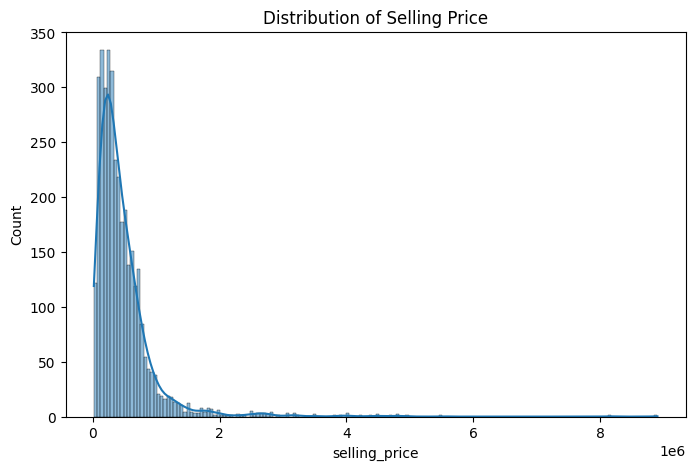

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['selling_price'],
    kde=True
)

plt.title("Distribution of Selling Price")

plt.show()

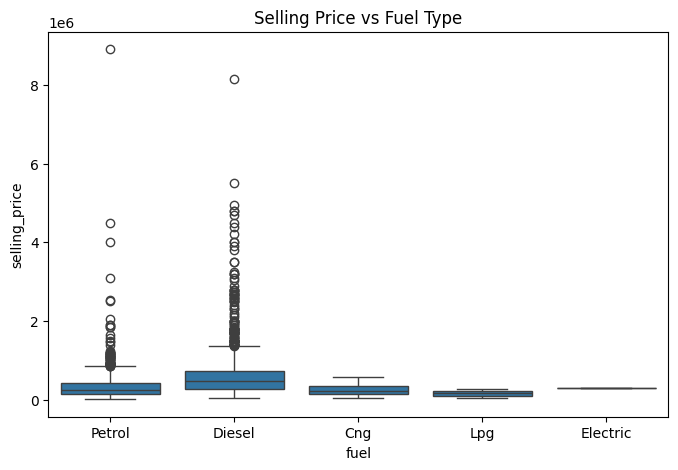

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='fuel',
    y='selling_price',
    data=df
)

plt.title("Selling Price vs Fuel Type")

plt.show()

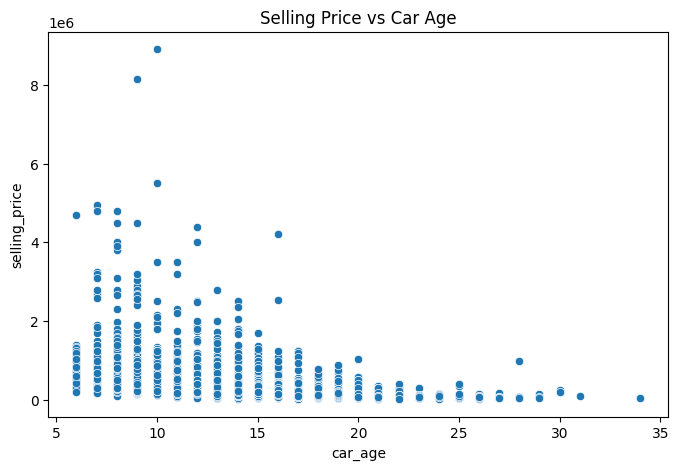

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='car_age',
    y='selling_price',
    data=df
)

plt.title("Selling Price vs Car Age")

plt.show()

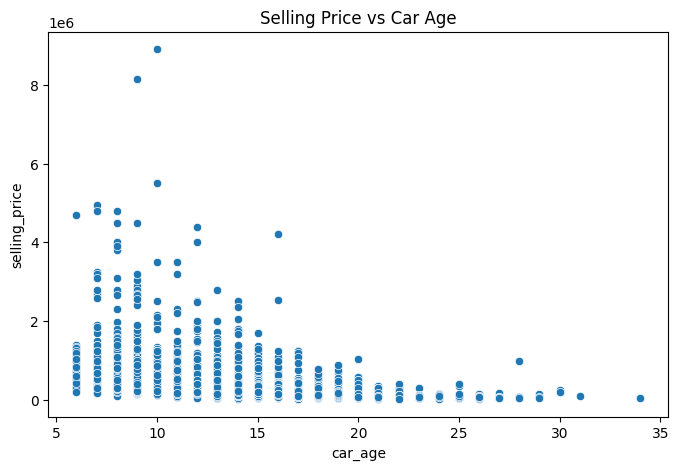

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='car_age',
    y='selling_price',
    data=df
)

plt.title("Selling Price vs Car Age")

plt.show()

In [15]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'fuel',
        'seller_type',
        'transmission',
        'owner',
        'brand'
    ],
    drop_first=True
)

In [16]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'fuel',
        'seller_type',
        'transmission',
        'owner',
        'brand'
    ],
    drop_first=True
)

In [17]:
X = df_encoded.drop(
    [
        'selling_price',
        'name',
        'year'
    ],
    axis=1
)

y = df_encoded['selling_price']

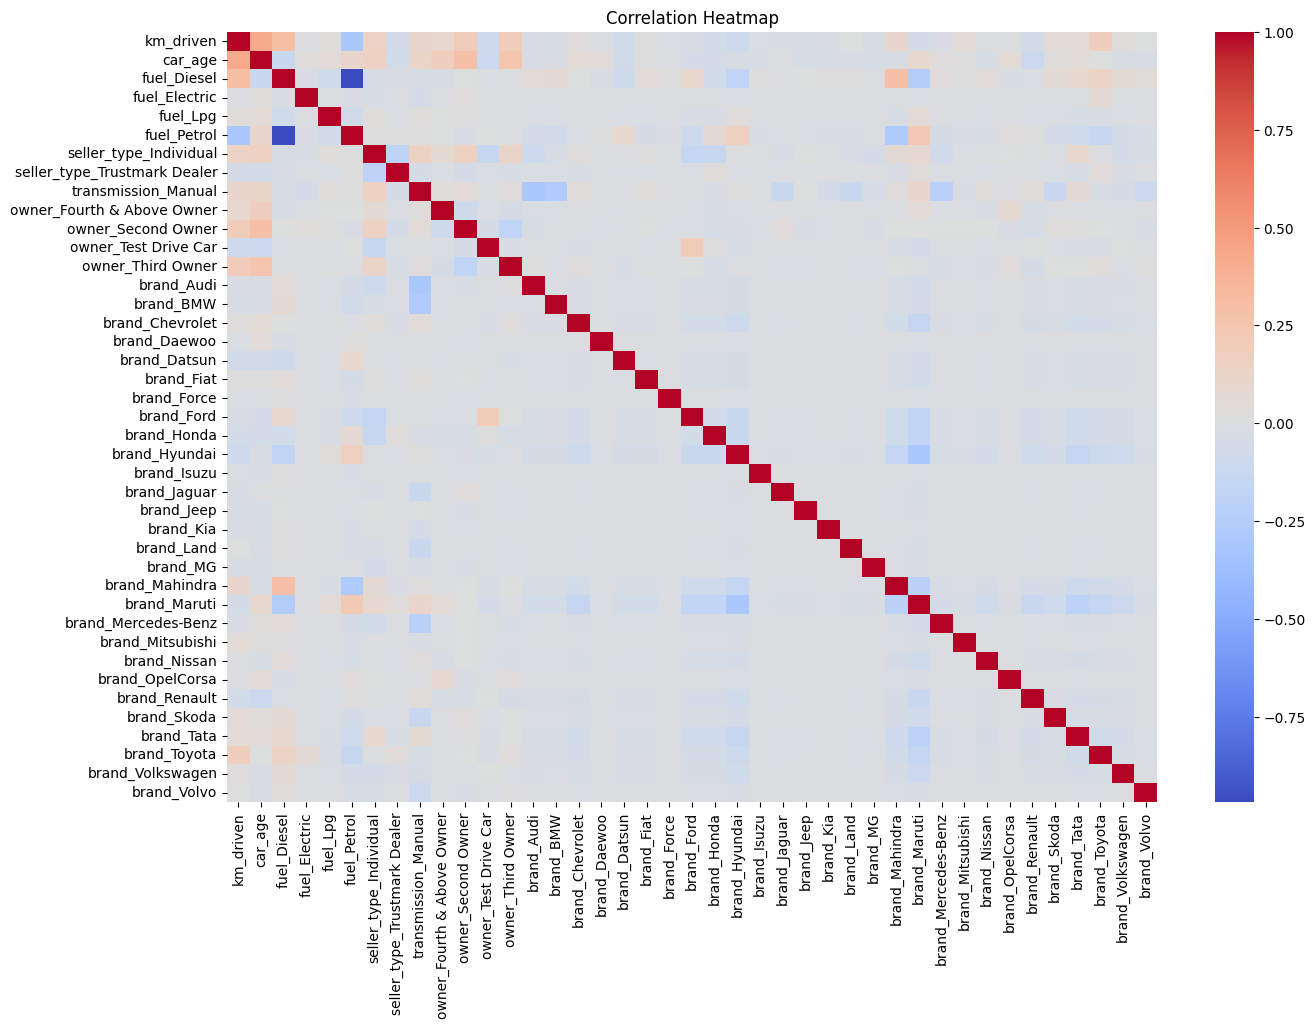

In [18]:
plt.figure(figsize=(15,10))

sns.heatmap(
    X.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression")

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 :", r2_lr)

Linear Regression
MAE : 180194.9870217033
RMSE : 385606.08609787765
R2 : 0.5384145989249838


In [22]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

In [23]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 :", r2_rf)

Random Forest
MAE : 158970.50799542782
RMSE : 368858.975989734
R2 : 0.5776378252413277


In [24]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest'
    ],
    'MAE':[
        mae_lr,
        mae_rf
    ],
    'RMSE':[
        rmse_lr,
        rmse_rf
    ],
    'R2 Score':[
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,180194.987022,385606.086098,0.538415
1,Random Forest,158970.507995,368858.975990,0.577638


In [25]:
if r2_rf > r2_lr:
    print("Best Model: Random Forest")
else:
    print("Best Model: Linear Regression")

Best Model: Random Forest


In [26]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
8,transmission_Manual,0.244025
1,car_age,0.222521
0,km_driven,0.141477
2,fuel_Diesel,0.063383
13,brand_Audi,0.052567
5,fuel_Petrol,0.050039
27,brand_Land,0.040486
38,brand_Toyota,0.037465
6,seller_type_Individual,0.017896
14,brand_BMW,0.013852


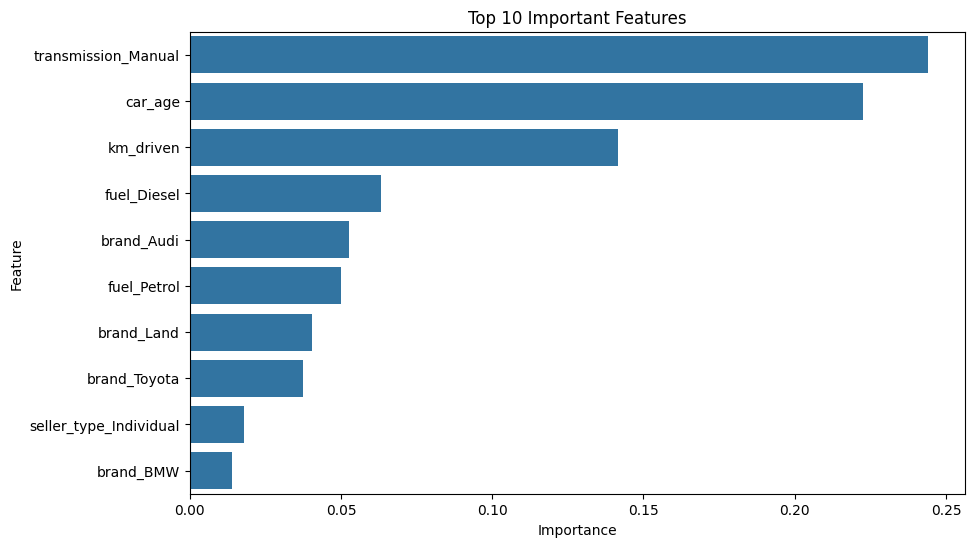

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [28]:
print("""
Conclusion:

1. Car Age negatively affects selling price.
2. Fuel type influences selling price.
3. Random Forest performs better than Linear Regression.
4. The most important features are:
   - Car Age
   - KM Driven
   - Brand
   - Fuel Type
   - Transmission
""")


Conclusion:

1. Car Age negatively affects selling price.
2. Fuel type influences selling price.
3. Random Forest performs better than Linear Regression.
4. The most important features are:
   - Car Age
   - KM Driven
   - Brand
   - Fuel Type
   - Transmission

